<a href="https://colab.research.google.com/github/JJsupercoder/BitVault/blob/master/Autonomous_Drone_Navigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generating a map of obstacles randomly for simulating drone movements in the obstacle grid

In [ ]:
# importing libs
import numpy as np
from math import cos, sin, pi, atan
import random


def generate_map(size_x, size_y, prob_of_one=0.2):
    '''A function which generates a random map of size (x,y) with a particular prob of 1's'''

    # creates a matrix of size (x,y) with random ints from 0 to 100
    map2d = np.random.randint(100, size=(size_x, size_y))

    # using map to convert all values to 0's and 1's, based on the prob of one (if rand no < 100*prob_of_one)
    map2d = list(map(lambda x: list((x < 100*prob_of_one)*1), map2d))

    return np.array(map2d)


def print_map(map2d, item_sep=' ', item_end='\n'):
    '''A simple function to print any 2D matrix for visulization purposes'''

    for row in map2d:
        for col in row:
            print(col, end=item_sep)
        print(item_end, end='')


In [ ]:
# Probability of obstacles, i.e. one's occuring in the map matrix
# Lower this value to generate more sparse obstacles.
# Dont increase it, otherwise closed off paths are formed.

prob_of_obstacles = 0.2

map_size = 50 # assuming a square area filled with obstacles

### This map shows the obstacle grid. 0 is an open path and 1 is an obstacle to avoid. Generating a static map here, but the drone will scan the map at every waypoint, so the obstacles in the map can be dynamic if needed.

In [ ]:
map2d = generate_map(map_size, map_size, prob_of_obstacles)

print_map(map2d)

0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 
0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 
0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 
0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 
0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 
0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 
1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 
0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 
1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 
1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1

# Defining the Waypoint Generation algorithm

In [ ]:
def generate_waypoint(src_x, src_y, dest_x, dest_y, map, grid_size=9):
    ''' A function which generates waypoints located at the boundaries of a grid and closest to the destination '''

    # We need one half of the grid because we're dealing with a quadrant, not the entire grid
    grid_size = grid_size//2

    ## If the destination coordinates is already in grid, return the destination coordinates.
    if src_x - grid_size <= dest_x <= src_x + grid_size and src_y - grid_size <= dest_y <= src_y + grid_size:
        return [[((dest_x-src_x+grid_size), (dest_y-src_y+grid_size)), 0]]

    # Variables containing sign of quadrant for moving from source to dest
    a = (-1)**(dest_x < src_x)
    b = (-1)**(dest_y < src_y)

    # generating the coordinates of the quadrant in the grid
    coords = [(a*grid_size, b*i) for i in range(grid_size+1)]
    coords.extend([(a*i, b*grid_size) for i in range(grid_size)])

    # adding the source coordinates to the generalized quandrant coordinates
    coordinates = [(coord[0]+grid_size, coord[1]+grid_size) for coord in coords]

    # maintaining a list of (manhattan dist from quadrant coord to dest coord, quadrant coordinates)
    manhattan_dist = [(abs(dest_x - coord[0] - src_x) + abs(dest_y -  coord[1] - src_y), coord) for coord in coordinates]

    # sorting the list according to manhattan dist to get closest waypoint
    manhattan_dist.sort(key = lambda x: x[0])

    possible_waypoints = []

    for dist, coord in manhattan_dist:
        # verify chosen waypoint in mini grid is not an obstacle itself
        if map[coord[0]][coord[1]] == 0:
            possible_waypoints.append([coord, dist])

    # return a list of waypoints in ascending order of distances in case the closest waypoint is unreachable
    return possible_waypoints


Defining a function to return the obstacles detected by the lidar. In this case, it takes from the map2d

In [ ]:
iter = 0
def get_lidar_obstacles(print_output=True):
    global iter, cur_x, cur_y
    iter += 1
    x_min = cur_x - grid_size//2
    x_max = cur_x + grid_size//2 + 1
    y_min = cur_y - grid_size//2
    y_max = cur_y + grid_size//2 + 1

    map = map2d[x_min:x_max, y_min:y_max]
    if print_output == True:
        print("Iteration", iter, ':', " Current Drone Coordinates:", (cur_x, cur_y))
        print_map(map)

    return map


# Defining the Q learning algorithm

In [ ]:
import random

class QLearning():
    def __init__(self, map, waypoint, n_epochs=100, max_iterations=100):
        self.agent_init_coord = (len(map)//2, len(map)//2)
        self.n_epochs = n_epochs
        self.max_iter = max_iterations
        self.epsilon = 0.4
        self.alpha = 0.15
        self.gamma = 0.9
        self.n = len(map)
        self.map = map
        self.n_actions = 8
        self.goal_state = waypoint
        self.q_table = self.gen_q_table()

    # Updation of Q table
    def gen_q_table(self):
        q_table = dict([])
        for r in range(self.n):
            for c in range(self.n):
                for actions in self.valid_actions((r,c)):
                    q_table[(r, c, actions)] = 0
        return q_table

    # Checking stopping condition
    def check_terminate(self, current_state):
        if current_state == self.goal_state:
            return True
        else:
            return False

    # Reward function for the agent
    def reward_function(self, next_state, current_state):
        if next_state == self.goal_state:
            return 100*(self.n/3)
        elif next_state == current_state:
            return -16
        elif abs(next_state[0] - current_state[0]) + abs(next_state[1] - current_state[1]) == 2:
            return -5.6569
        else:
            return -4

    # Epsilon greedy method to determine whether to explore or exploit
    def epsilon_greedy(self, converge = False):
        if converge == True:
            if self.epsilon > 0:
                self.epsilon -= 0.05
            if self.epsilon < 0.15:
                self.epsilon = 0.15

        if self.epsilon >= random.random():
            return "Exploration"
        else:
            return "Exploitation"

    # A function which returns valid actions
    def valid_actions(self, current_state):
        actions = []
        r = current_state[0]
        c = current_state[1]
        m = self.map
        if r-1>=0 and c-1>=0 and str(m[r][c-1])+str(m[r-1][c-1])+str(m[r-1][c]) == '000':
            actions.append(0)
        if r-1>=0 and m[r-1][c] == 0:
            actions.append(1)
        if r-1>=0 and c+1<self.n and str(m[r-1][c])+str(m[r-1][c+1])+str(m[r][c+1]) == '000':
            actions.append(2)
        if c-1>=0 and m[r][c-1] == 0:
            actions.append(3)
        if c+1<self.n and m[r][c+1] == 0:
            actions.append(4)
        if r+1<self.n and c-1>=0 and str(m[r][c-1])+str(m[r+1][c-1])+str(m[r+1][c]) == '000':
            actions.append(5)
        if r+1<self.n and m[r+1][c] == 0:
            actions.append(6)
        if r+1<self.n and c+1<self.n and str(m[r+1][c])+str(m[r+1][c+1])+str(m[r][c+1]) == '000':
            actions.append(7)
        return actions

    # returns the best action according to the policy
    def policy(self, state):
        actions = self.valid_actions(state)
        options = [self.q_table[(state[0], state[1], action)] for action in actions]
        best_action = actions[options.index(max(options))]
        return best_action

    # Action performed by the agent
    def perform_action(self, current_state, action):
        action_coord_add = {0:(-1,-1), 1:(-1,0), 2:(-1,1), 3:(0,-1), 4:(0,1), 5:(1,-1), 6:(1,0), 7:(1,1)}
        coord_add = action_coord_add[action]
        next_state = (current_state[0] + coord_add[0], current_state[1] + coord_add[1])
        r = next_state[0]
        c = next_state[1]
        if not((0<=r<=self.n-1) and (0<=c<=self.n-1) and self.map[r][c]==0):# and action in self.valid_actions(current_state)):
            return current_state
        return next_state

    # Training section
    def train(self):
        for episode in range(self.n_epochs):
            step = 0
            done = False
            current_state = self.agent_init_coord
            while (step <= self.max_iter and done == False):
                step += 1
                actions = self.valid_actions(current_state)
                if self.epsilon_greedy(converge = True) == "Exploration":
                    current_action = random.choice(actions)
                else: #exploitation
                    current_action = self.policy(current_state)

                # Take the current_action and Observe reward R, next state S'
                next_state = self.perform_action(current_state, current_action)
                R = self.reward_function(next_state, current_state)
                q_next_state = [self.q_table[(next_state[0], next_state[1], action)] for action in self.valid_actions(next_state)]
                self.q_table[(current_state[0], current_state[1], current_action)] += (self.alpha * (R + self.gamma*max(q_next_state) - self.q_table[(current_state[0], current_state[1], current_action)]))
                current_state = next_state
                done = self.check_terminate(current_state)


    # Testing section
    def test(self):
        step = 0
        done = False
        current_state = self.agent_init_coord
        reward = 0
        current_action = 8
        chosen_moves = []
        while step <= self.max_iter and done == False:
            ## Displaying live terrain grid (UI Part)
            # move_name = ("Top left", "Up", "Top right", "Left", "Right", "Bottom left", "Down", "Bottom right", "None")
            # print("Action Taken:", move_name[current_action])
            # print("Current State:", current_state)
            # live_terr_grid(self.n, -2, self.map, current_state, step, False)
            # print("-"*20)

            step += 1
            current_action = self.policy(current_state)
            chosen_moves.append(current_action)
            # Take the current_action and Observe reward R, next state S'
            next_state = self.perform_action(current_state, current_action)
            R = self.reward_function(next_state, current_state)
            reward += R
            current_state = next_state
            done = self.check_terminate(current_state)

        # print("Results:")
        # print("Reward: ", reward, "\nNumber of moves: ",step)
        move_name = ("Top left", "Up", "Top right", "Left", "Right", "Bottom left", "Down", "Bottom right", "None")
        moves = [move_name[i] for i in chosen_moves]
        return done, moves, current_state


    # Testing section and visualize output
    def visualized_test(self):
        step = 0
        done = False
        current_state = self.agent_init_coord
        reward = 0
        current_action = 8
        while step <= self.max_iter and done == False:
            # Displaying live terrain grid (UI Part)
            move_name = ("Top left", "Up", "Top right", "Left", "Right", "Bottom left", "Down", "Bottom right", "None")
            print("Action Taken:", move_name[current_action])
            live_terr_grid(self.n, -2, self.map, current_state, step, False)
            print("-"*20)

            step += 1
            current_action = self.policy(current_state)
            # Take the current_action and Observe reward R, next state S'
            next_state = self.perform_action(current_state, current_action)
            R = self.reward_function(next_state, current_state)
            reward += R
            current_state = next_state
            done = self.check_terminate(current_state)

        # Displaying live terrain grid (UI Part)
        move_name = ("Top left", "Up", "Top right", "Left", "Right", "Bottom left", "Down", "Bottom right", "None")
        print("Action Taken:", move_name[current_action])
        live_terr_grid(self.n, -2, self.map, current_state, step, False)
        print("-"*20)

        # print("Results:")
        # print("Reward: ", reward, "\nNumber of moves: ",step)
        return done, current_state

In [ ]:
# UI part for the program
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import copy
import time

iters = 0
# Printing live status of the visited tiles in the terrain grid
def live_terr_grid(n, h, map, curr, step, animate=False):
    if(animate):
        time.sleep(0.1)
        clear_output()
    data = copy.deepcopy(map)
    data[curr[0]][curr[1]] = -1

    cmap = plt.cm.get_cmap("bwr")

    plt.figure(figsize=(n, n))
    plt.imshow(data, cmap=cmap, vmin=-h, vmax=h)
    global iters
    iters += 1
    plt.colorbar(orientation='horizontal')
    plt.title("Episode: "+str(iter)+ "  Move: "+str(step))
    plt.show();


# Defining the Path Planning Algorithm for source to destination traversal

Path Planning uses Waypoints as goal states for the Q learning algorithm

In [ ]:
## Defining the src and dest coordinates here

# grid_size = int(input("Enter the range of the sensor grid (grid size): "))
grid_size = 9

# init_x, init_y = map(int, input("Enter the Drone Initial Coordinates comma separated: ").split(','))
# while (grid_size <= init_x < len(map2d)-grid_size) or (grid_size <= init_y < len(map2d[0]-grid_size)):
#     print("Initial X and Y Coordinates can only lie in the map, i.e. between", grid_size, "and", len(map2d)-grid_size-1)
#     init_x, init_y = map(int, input("Enter the Drone Initial Coordinates comma separated: ").split(','))

init_x, init_y = 10,10

# dest_x, dest_y = map(int, input("Enter the Drone Destination Coordinates comma separated: ").split(','))
# while (grid_size <= dest_x < len(map2d)-grid_size) or (grid_size <= dest_y < len(map2d[0]-grid_size)) or map2d[dest_x][dest_y] != 0:
#     print("Destination X and Y Coordinates can only lie in the map, i.e. between", grid_size, "and", len(map2d)-grid_size-1)
#     print("Map[dest_x][dest_y] =", map[dest_x][dest_y], " should not be an obstacle, i.e. 1")
#     dest_x, dest_y = map(int, input("Enter the Drone Destination Coordinates comma separated: ").split(','))

dest_x, dest_y = 30,35

iter = 0
cur_x, cur_y = init_x, init_y

## Main loop which runs till the drone reaches the destination

In [ ]:
# The main loop which runs till destination is reached
while (cur_x, cur_y) != (dest_x, dest_y) and iter < 100:
    lidar_map = get_lidar_obstacles()
    waypoints = generate_waypoint(cur_x, cur_y, dest_x, dest_y, lidar_map, grid_size)
    x,y = cur_x, cur_y

    for waypoint, dist in waypoints:
        print('\nChosen Waypoint:', (waypoint[0]+cur_x-grid_size//2, waypoint[1]+cur_y-grid_size//2))
        path_plan = QLearning(lidar_map, waypoint)
        path_plan.train()
        done, actions, coord = path_plan.test()

        if done == True:
            print("Actions Taken:", actions, end='\n\n')
            cur_x, cur_y = coord[0] + cur_x - grid_size//2, coord[1] + cur_y - grid_size//2
            break

print("Drone has reached the destination:", (cur_x, cur_y))

Iteration 1 :  Current Drone Coordinates: (10, 10)
0 0 0 1 0 0 0 0 0 
1 1 1 0 0 0 1 0 1 
0 1 1 0 0 0 0 0 0 
1 1 0 1 0 0 1 0 1 
0 0 1 0 0 0 0 0 0 
0 1 0 0 0 0 0 0 0 
0 0 0 0 1 0 0 0 1 
1 1 0 0 1 0 0 0 0 
0 1 0 0 0 0 0 0 0 

Chosen Waypoint: (14, 14)
Actions Taken: ['Bottom right', 'Bottom right', 'Bottom right', 'Bottom right']

Iteration 2 :  Current Drone Coordinates: (14, 14)
0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 1 0 
1 0 0 0 1 0 0 0 0 
1 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 1 1 0 
0 0 0 0 0 1 1 1 0 
0 0 0 1 0 0 0 0 0 
0 1 0 0 1 0 0 1 0 
0 1 0 0 0 0 0 0 0 

Chosen Waypoint: (18, 18)
Actions Taken: ['Down', 'Down', 'Right', 'Bottom right', 'Down', 'Right', 'Right']

Iteration 3 :  Current Drone Coordinates: (18, 18)
0 0 1 1 0 0 1 0 0 
0 1 1 1 0 1 0 0 0 
0 0 0 0 0 0 1 0 0 
1 0 0 1 0 1 0 0 0 
0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 1 1 0 
0 1 0 0 0 1 0 0 0 
0 1 1 1 0 0 1 0 1 
0 0 0 1 0 0 0 0 0 

Chosen Waypoint: (22, 22)
Actions Taken: ['Down', 'Down', 'Down', 'Bottom right', 'Right', 'Right', 'Right']

Iter

# Visualizing the drone movements in a better way -

In [ ]:
## Defining the src and dest coordinates here

# grid_size = int(input("Enter the range of the sensor grid (grid size): "))
grid_size = 9

# init_x, init_y = map(int, input("Enter the Drone Initial Coordinates comma separated: ").split(','))
# while (grid_size <= init_x < len(map2d)-grid_size) or (grid_size <= init_y < len(map2d[0]-grid_size)):
#     print("Initial X and Y Coordinates can only lie in the map, i.e. between", grid_size, "and", len(map2d)-grid_size-1)
#     init_x, init_y = map(int, input("Enter the Drone Initial Coordinates comma separated: ").split(','))

init_x, init_y = 10,10

# dest_x, dest_y = map(int, input("Enter the Drone Destination Coordinates comma separated: ").split(','))
# while (grid_size <= dest_x < len(map2d)-grid_size) or (grid_size <= dest_y < len(map2d[0]-grid_size)) or map2d[dest_x][dest_y] != 0:
#     print("Destination X and Y Coordinates can only lie in the map, i.e. between", grid_size, "and", len(map2d)-grid_size-1)
#     print("Map[dest_x][dest_y] =", map[dest_x][dest_y], " should not be an obstacle, i.e. 1")
#     dest_x, dest_y = map(int, input("Enter the Drone Destination Coordinates comma separated: ").split(','))

dest_x, dest_y = 30,35

iter = 0
cur_x, cur_y = init_x, init_y

## The drone starts at the centre of the grid at every episode. It scans its surroundings to view the obstacle map and gets the data from the lidar sensors (since we didnt connect to a real time drone and lidar, we're taking a subset taken from the grid3D map in our case). It reaches the waypoint which is at the corner of the grid (in the general direction of the destination). Repeat this procedure till the drone reaches the destination.


Chosen Waypoint: (14, 14)
Action Taken: None


<ipython-input-376-ec04301898b2>:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("bwr")


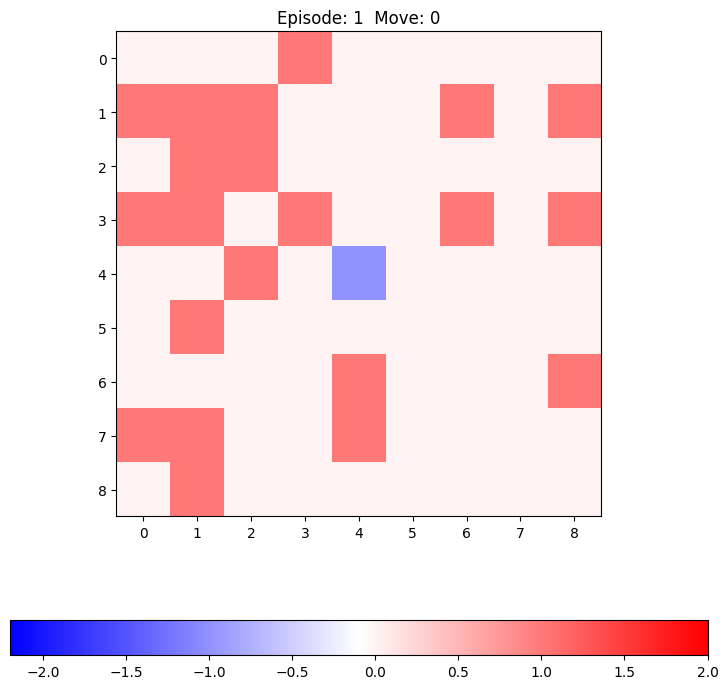

--------------------
Action Taken: Right


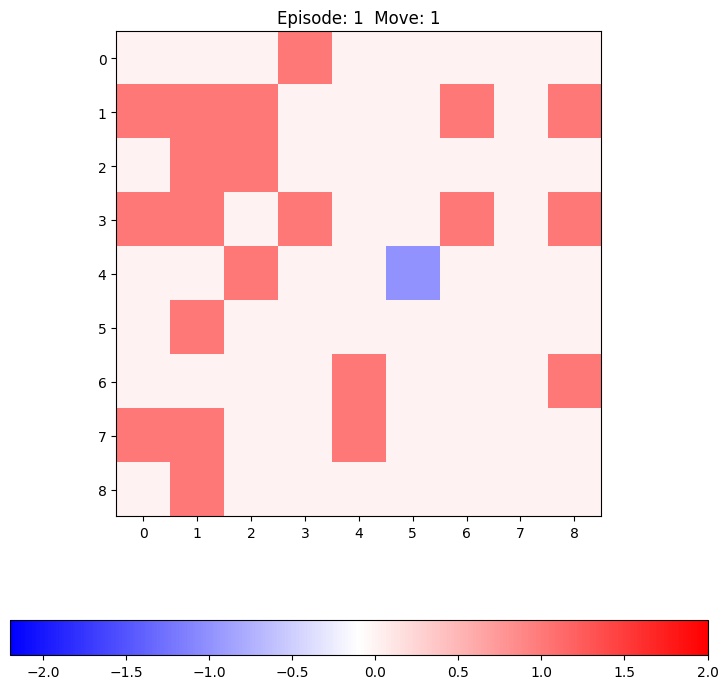

--------------------
Action Taken: Bottom right


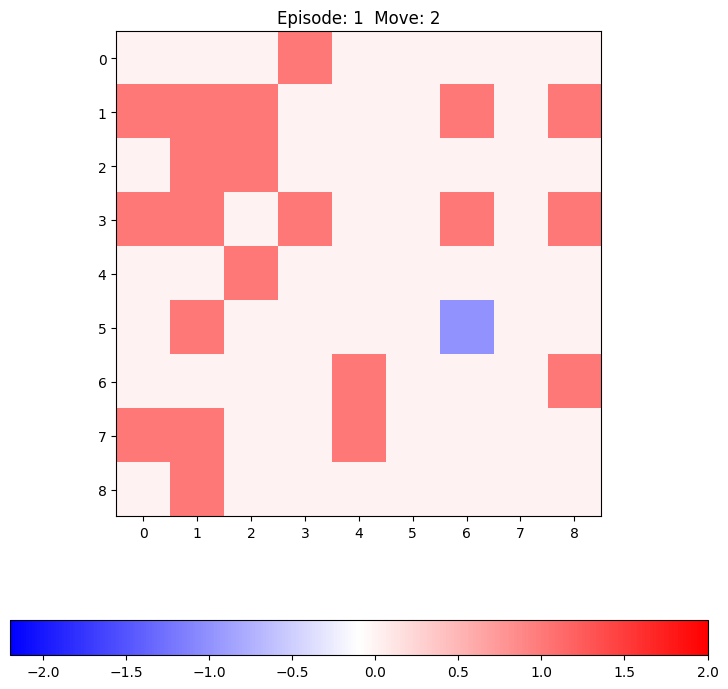

--------------------
Action Taken: Bottom right


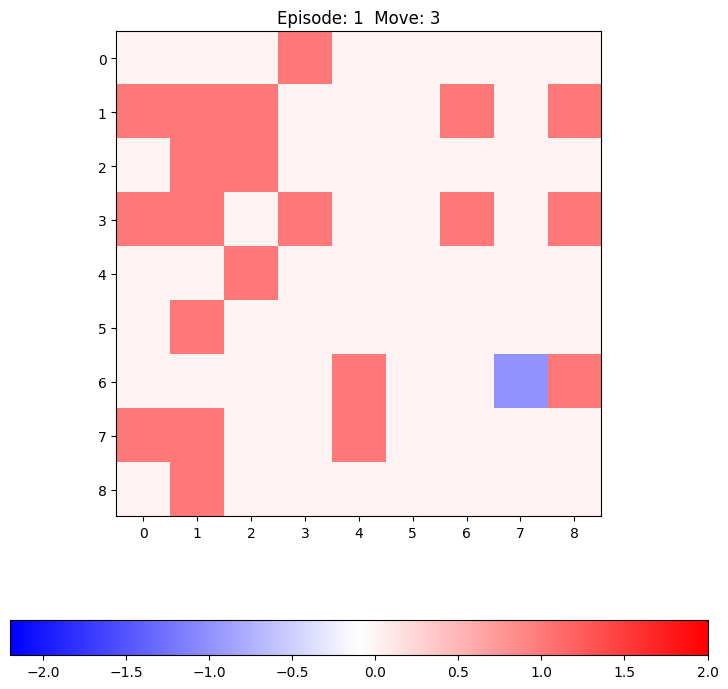

--------------------
Action Taken: Down


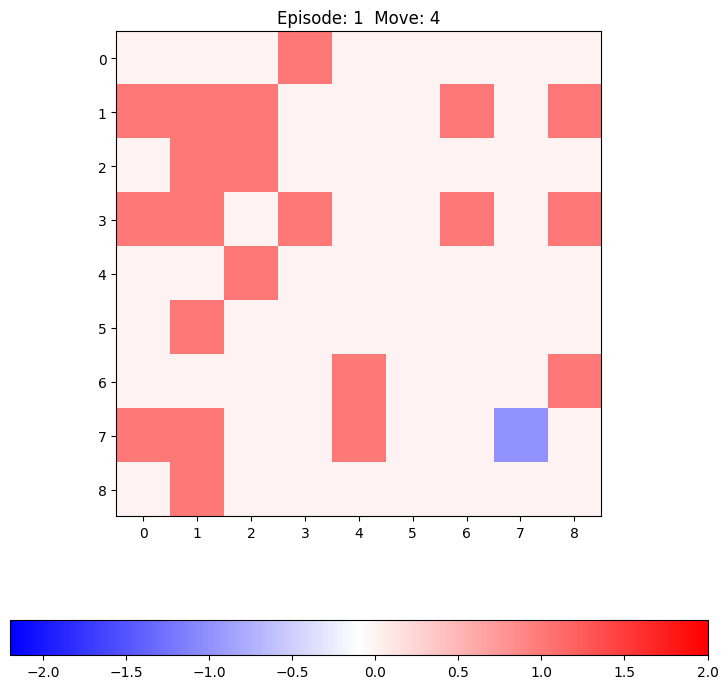

--------------------
Action Taken: Bottom right


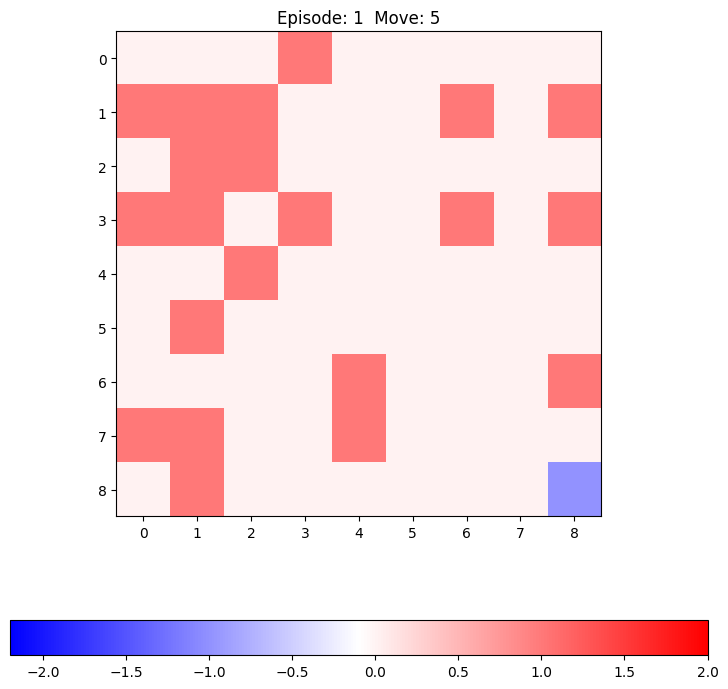

--------------------

Chosen Waypoint: (18, 18)
Action Taken: None


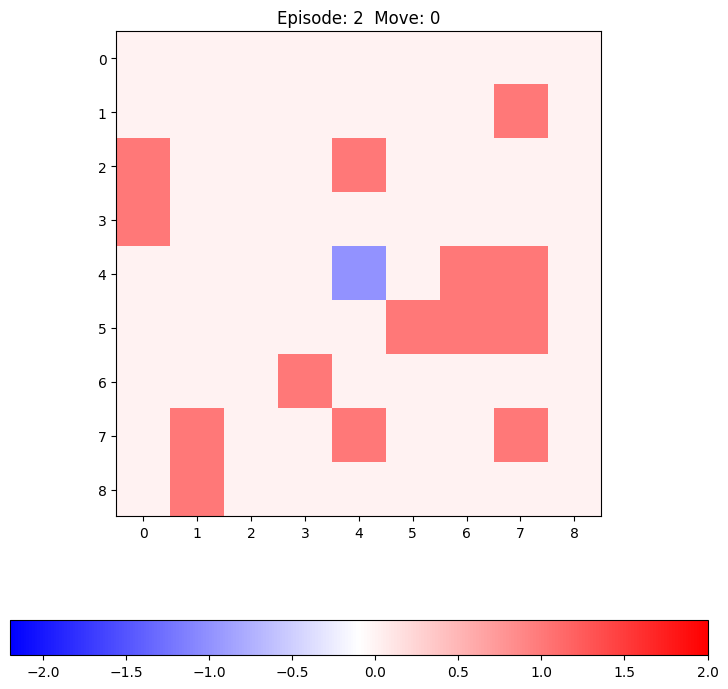

--------------------
Action Taken: Down


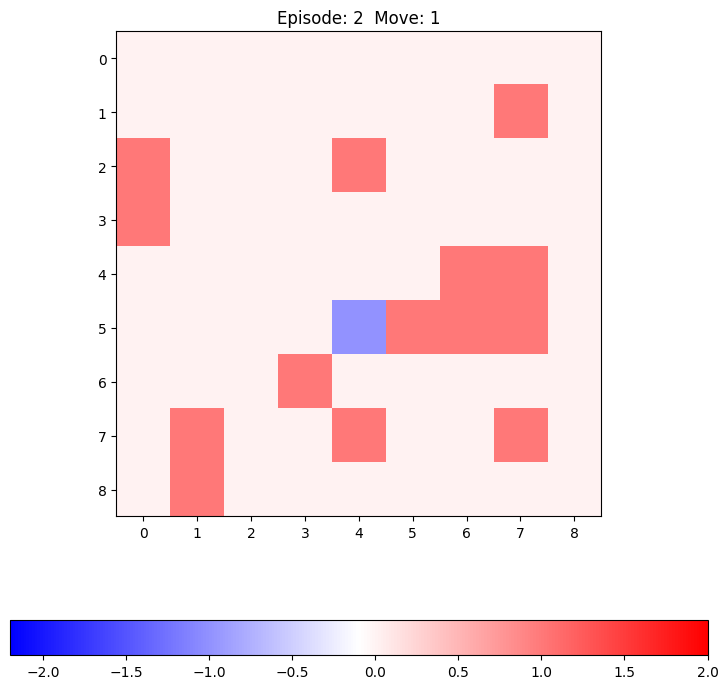

--------------------
Action Taken: Down


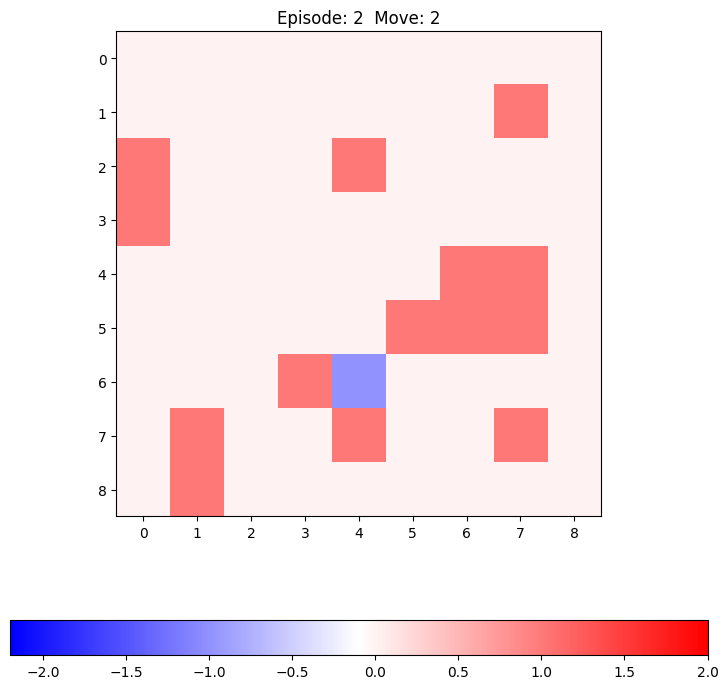

--------------------
Action Taken: Right


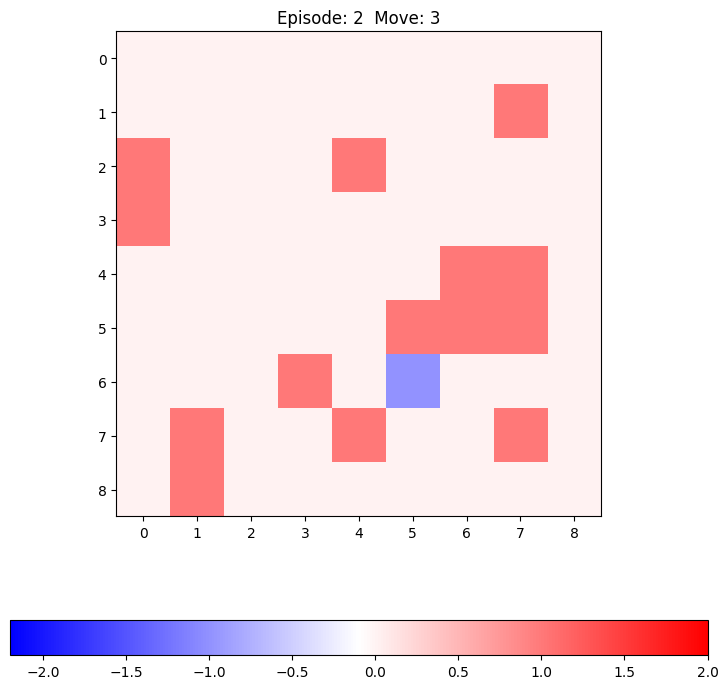

--------------------
Action Taken: Down


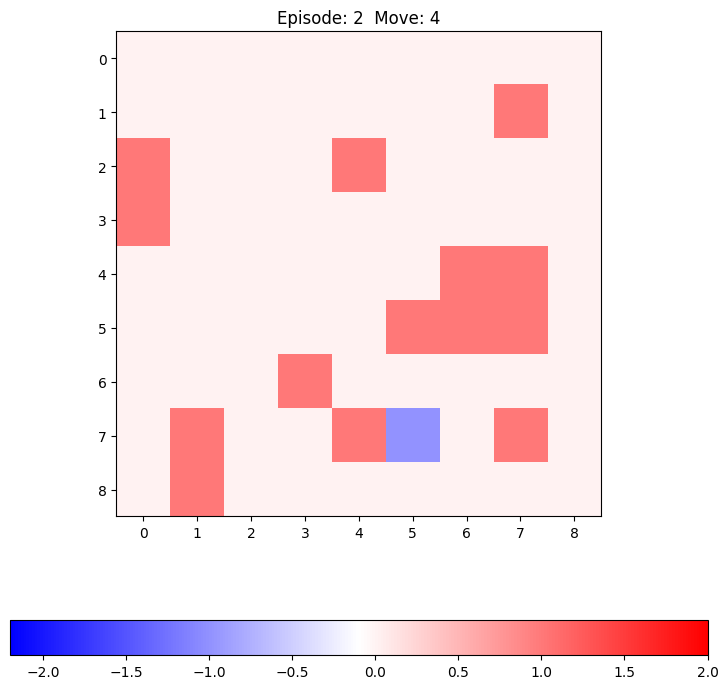

--------------------
Action Taken: Bottom right


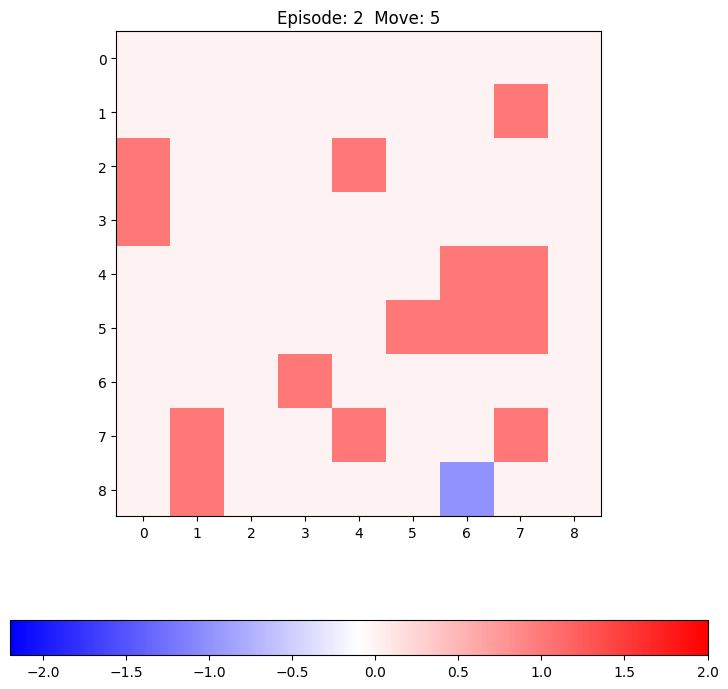

--------------------
Action Taken: Right


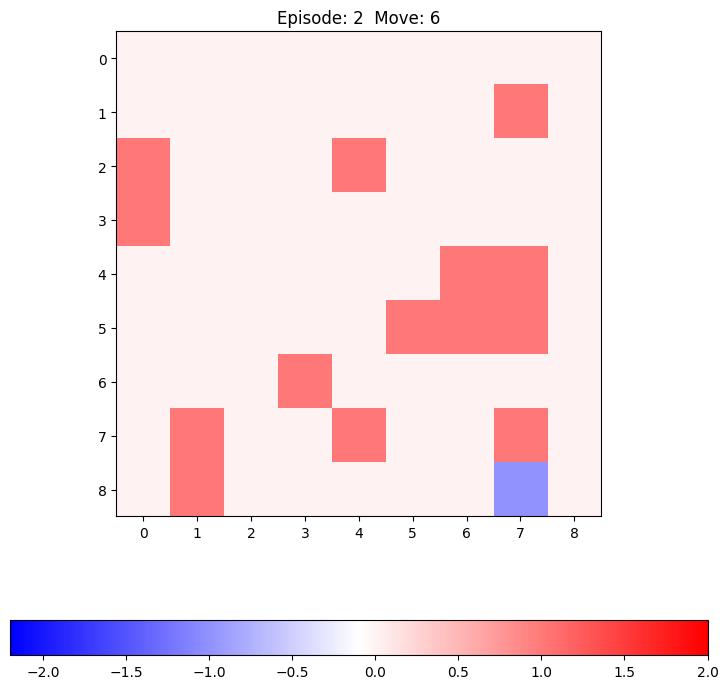

--------------------
Action Taken: Right


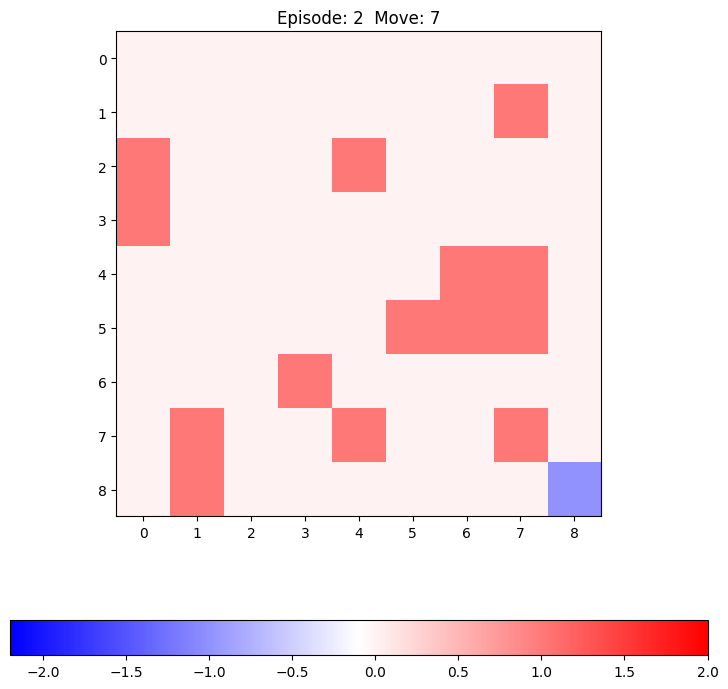

--------------------

Chosen Waypoint: (22, 22)
Action Taken: None


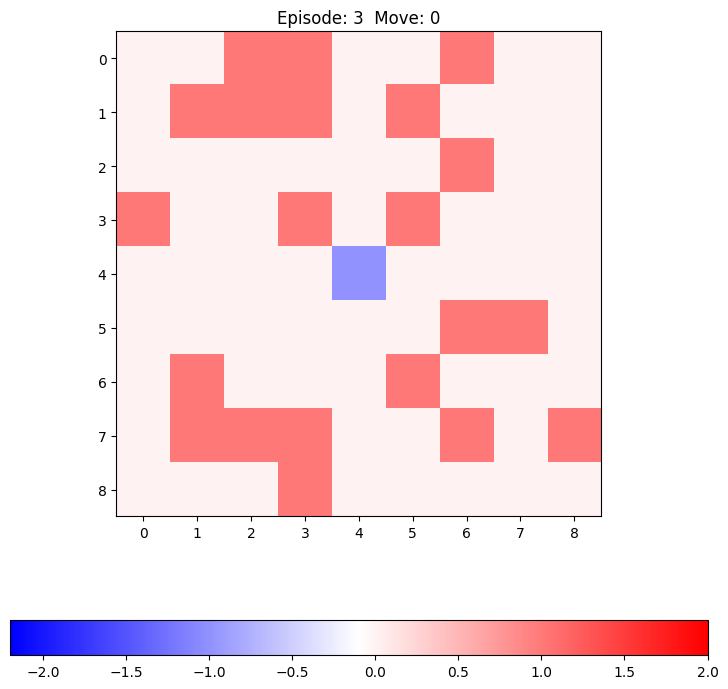

--------------------
Action Taken: Down


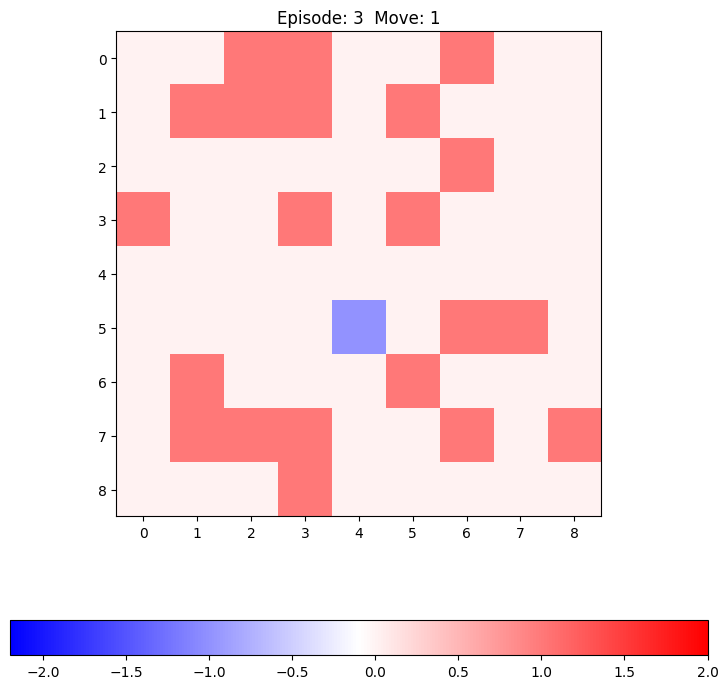

--------------------
Action Taken: Down


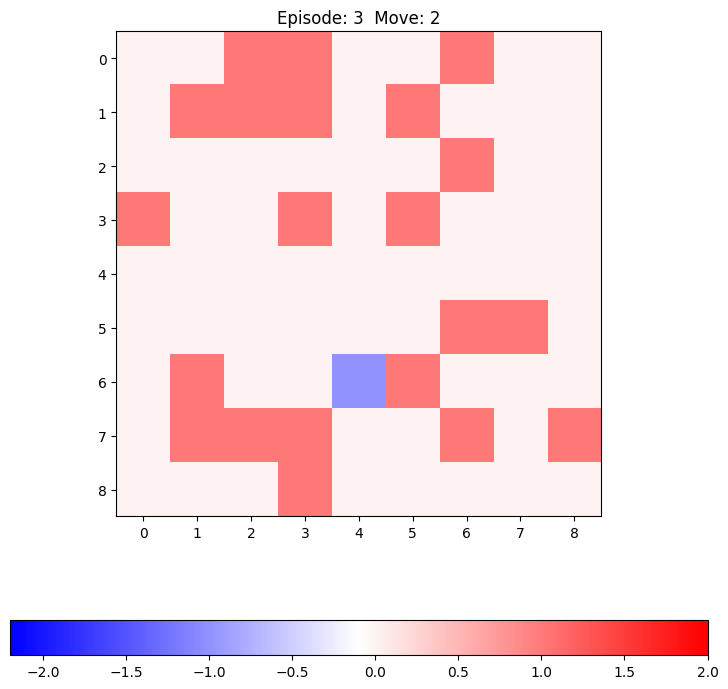

--------------------
Action Taken: Down


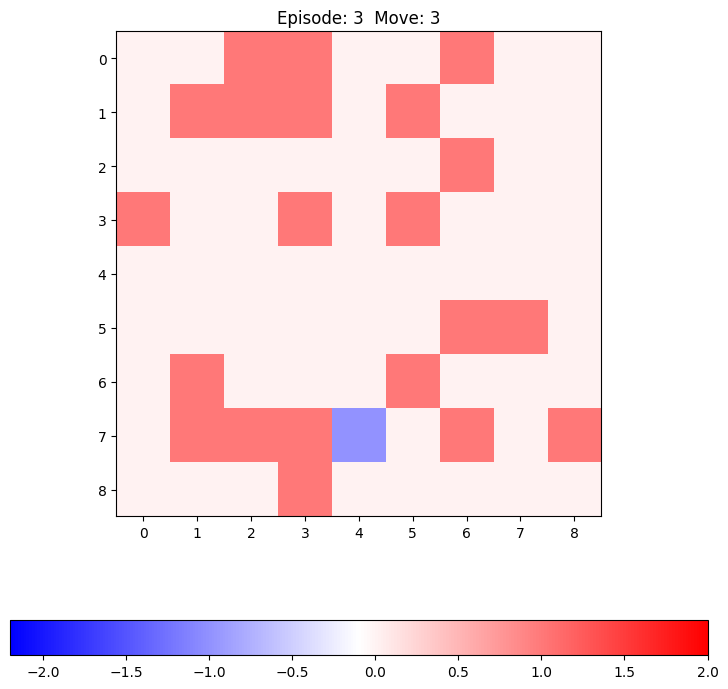

--------------------
Action Taken: Bottom right


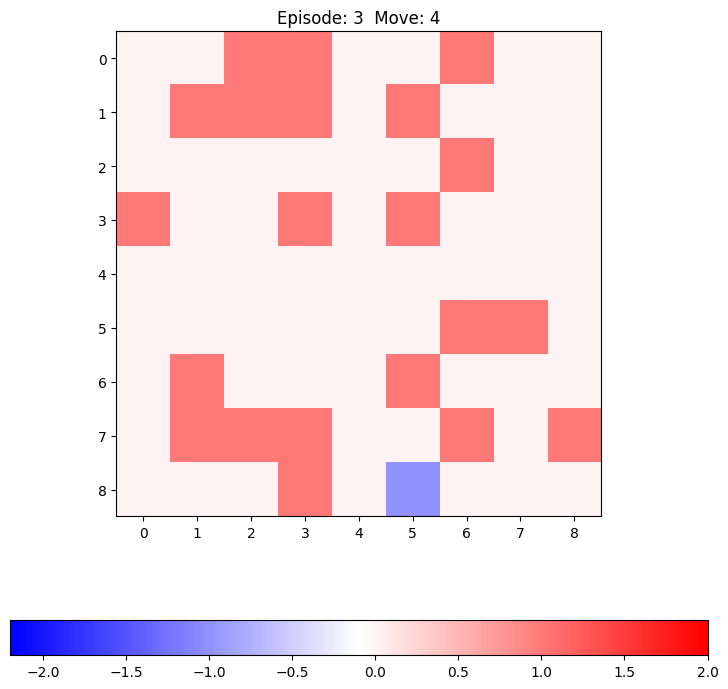

--------------------
Action Taken: Right


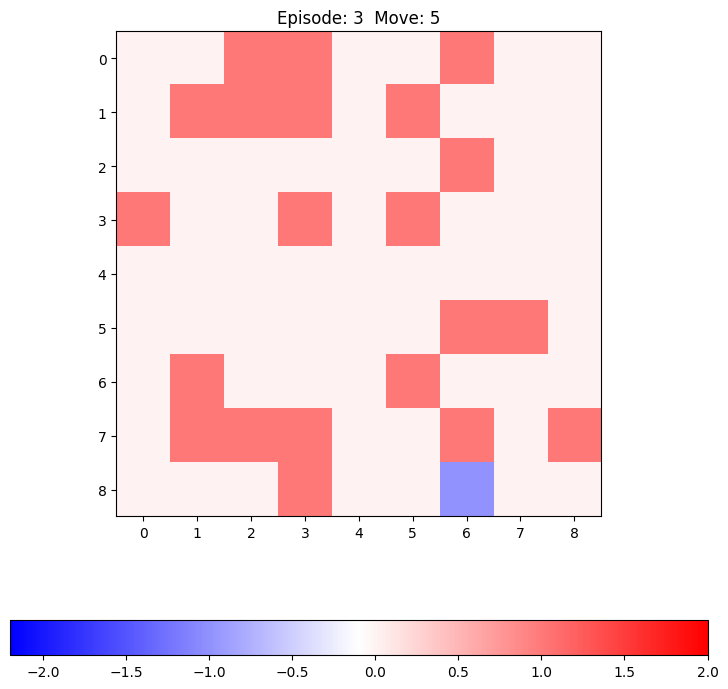

--------------------
Action Taken: Right


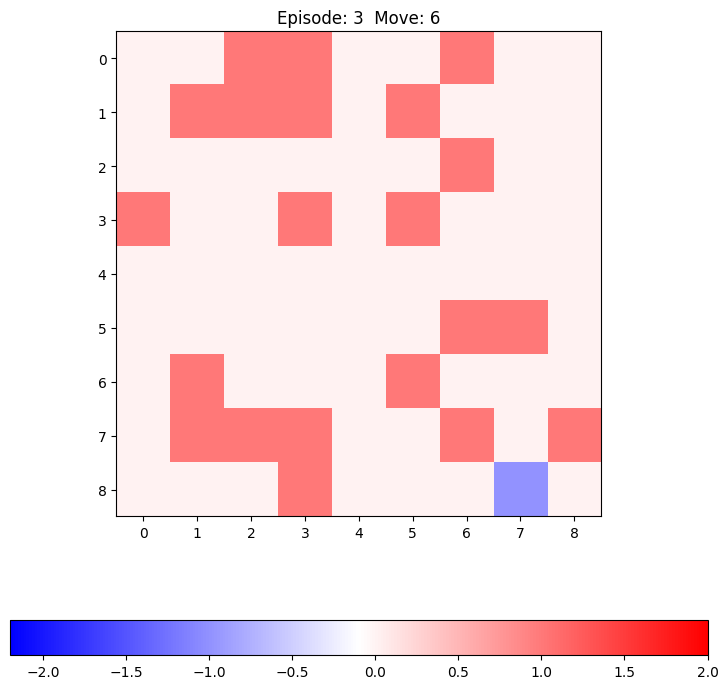

--------------------
Action Taken: Right


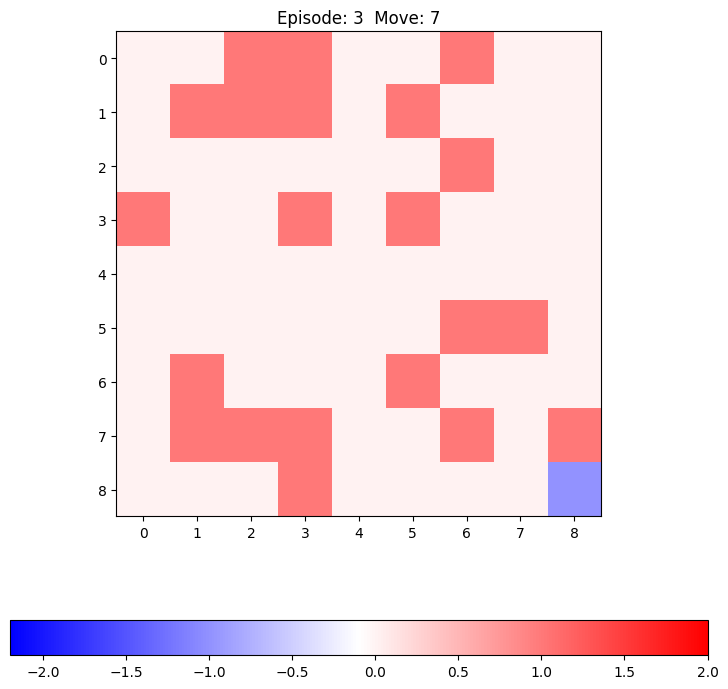

--------------------

Chosen Waypoint: (26, 26)
Action Taken: None


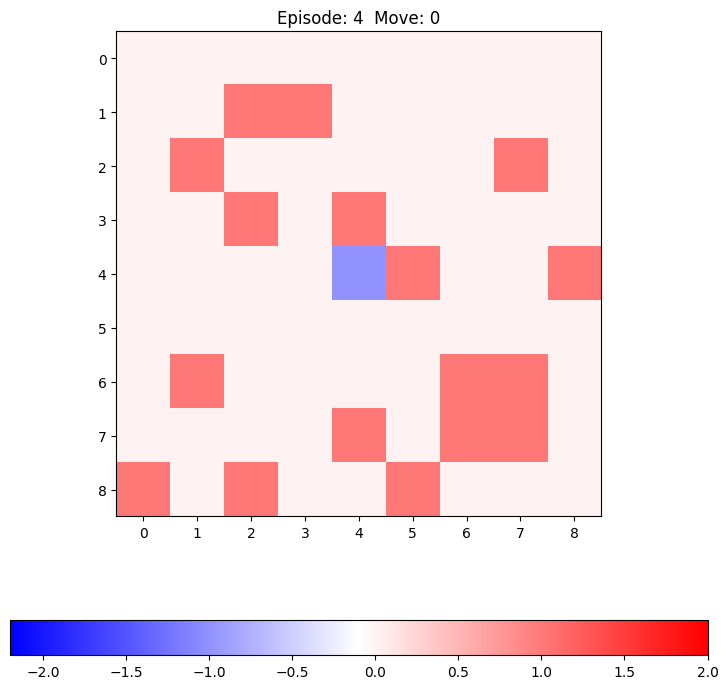

--------------------
Action Taken: Down


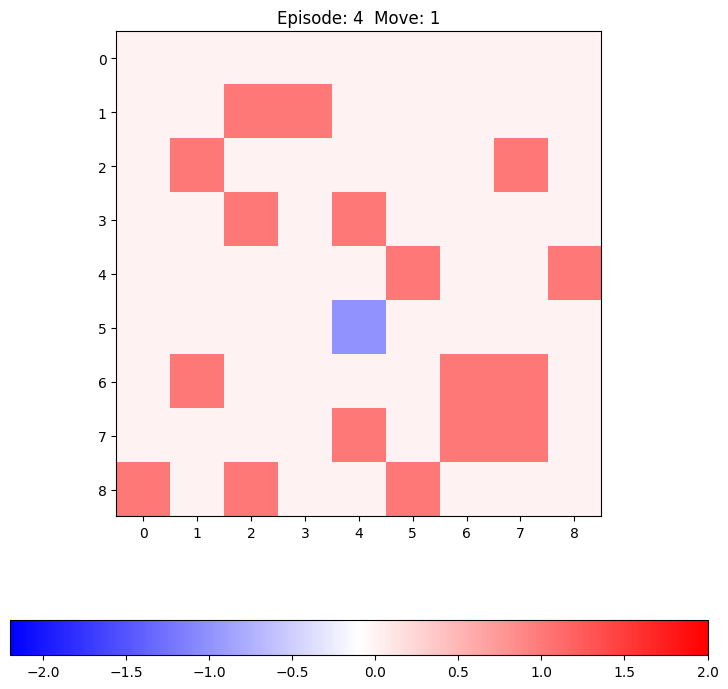

--------------------
Action Taken: Right


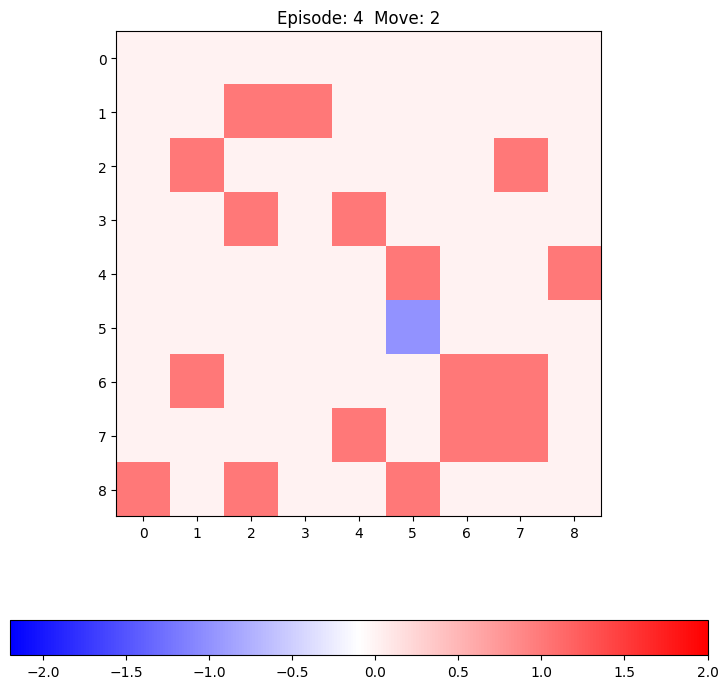

--------------------
Action Taken: Right


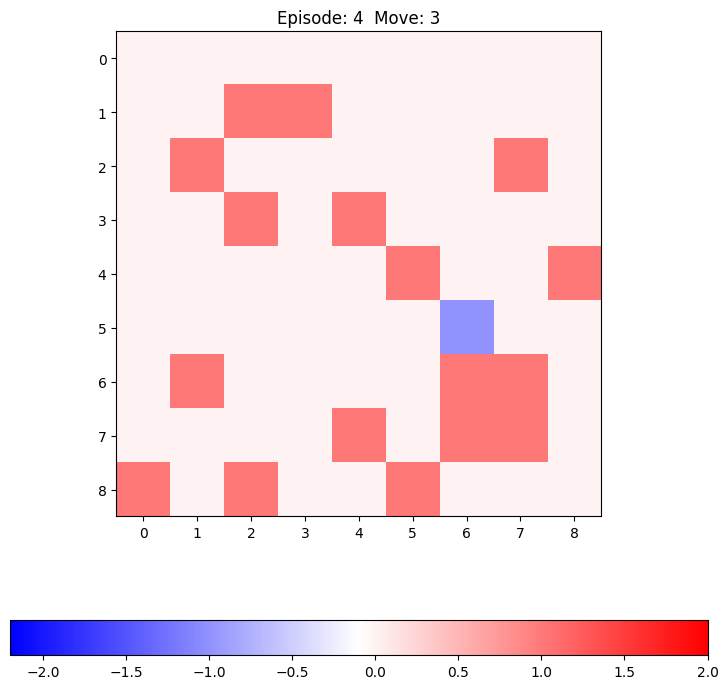

--------------------
Action Taken: Right


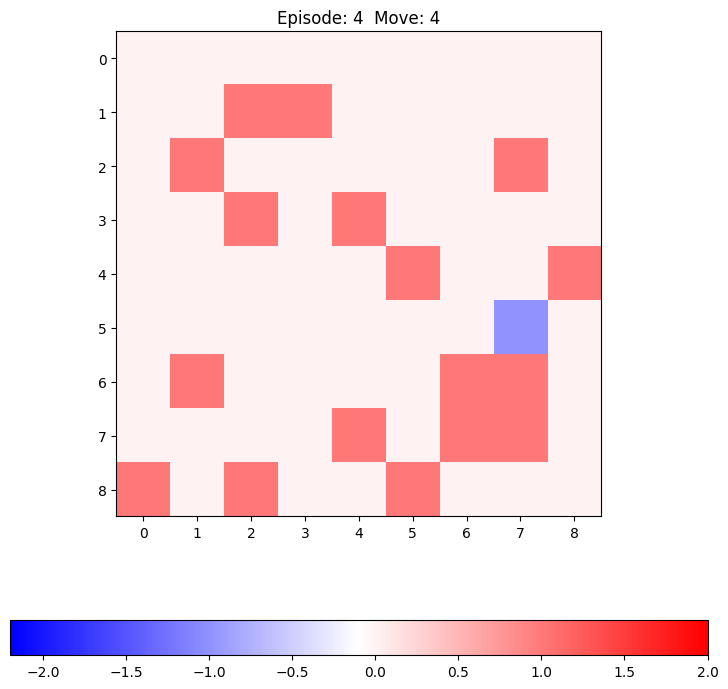

--------------------
Action Taken: Right


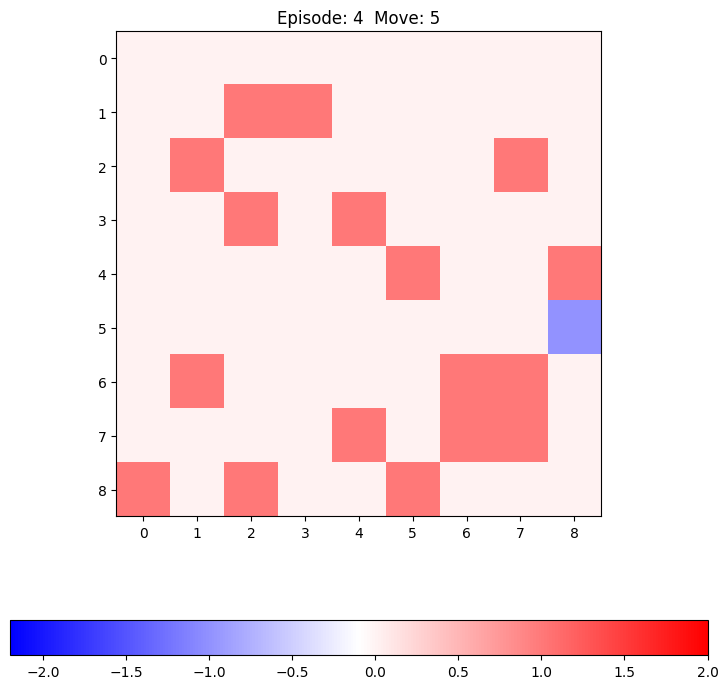

--------------------
Action Taken: Down


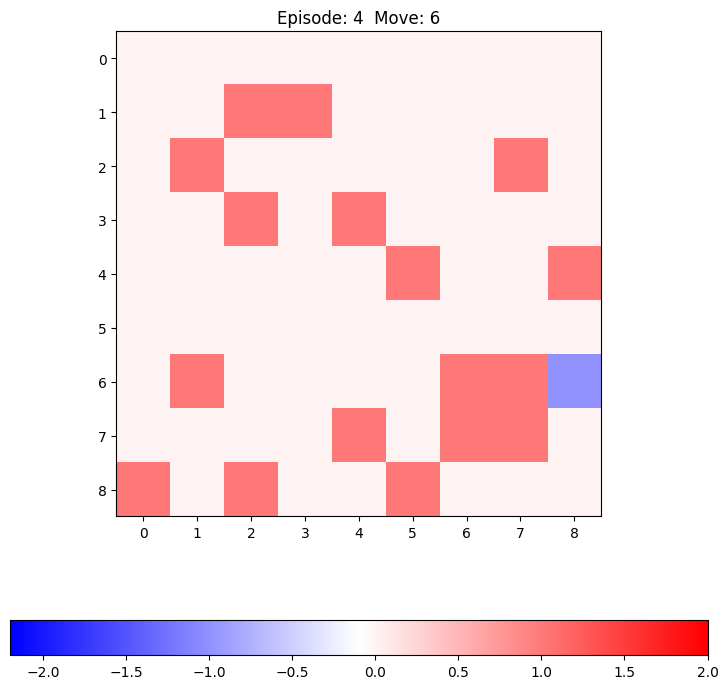

--------------------
Action Taken: Down


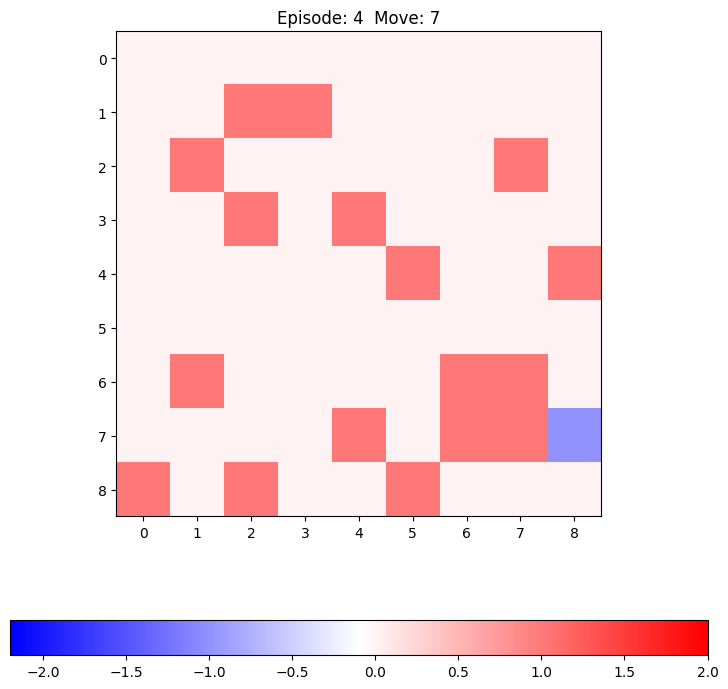

--------------------
Action Taken: Down


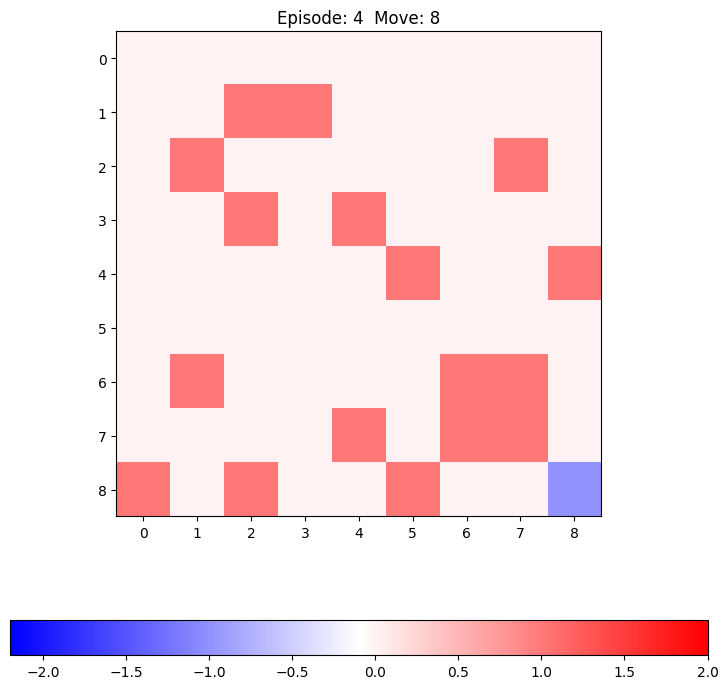

--------------------

Chosen Waypoint: (26, 30)
Action Taken: None


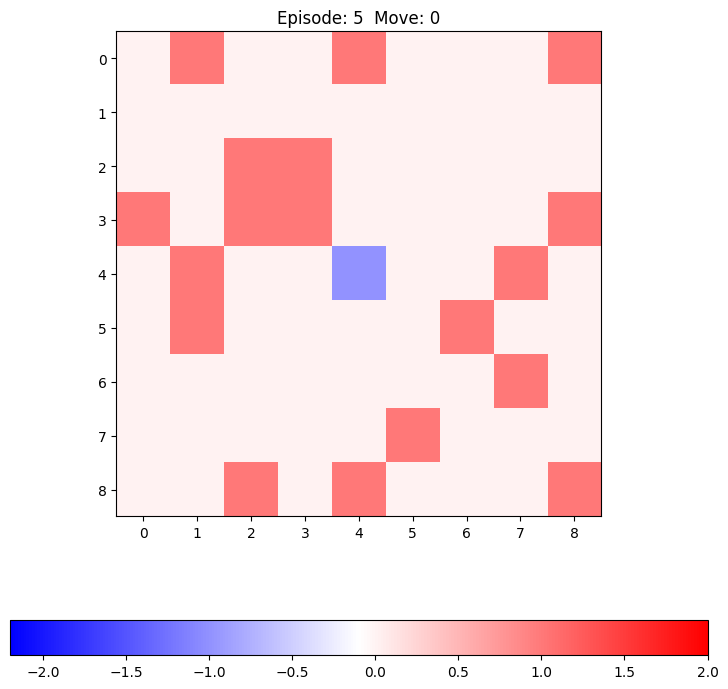

--------------------
Action Taken: Down


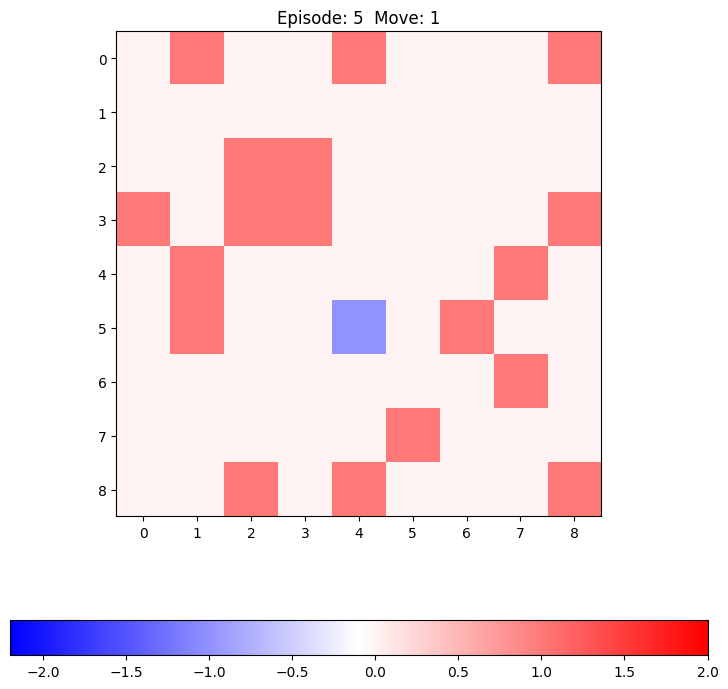

--------------------
Action Taken: Bottom right


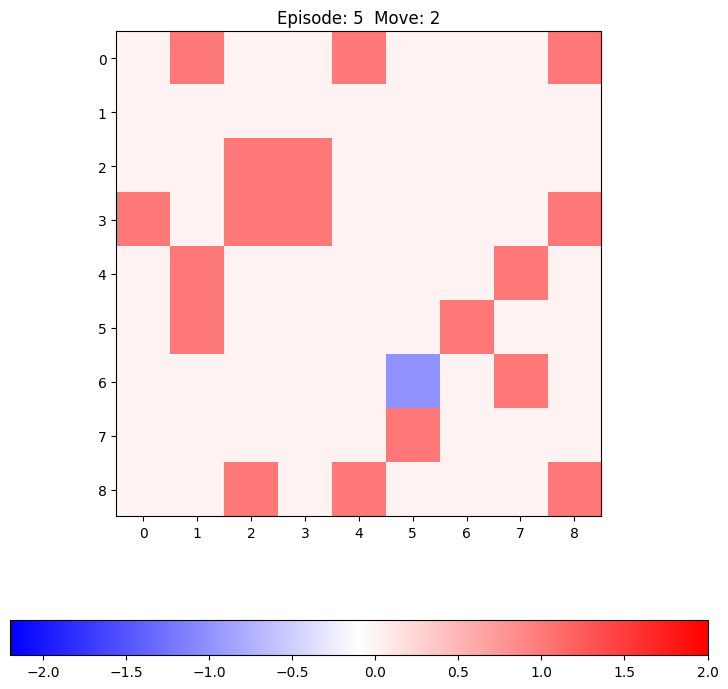

--------------------
Action Taken: Right


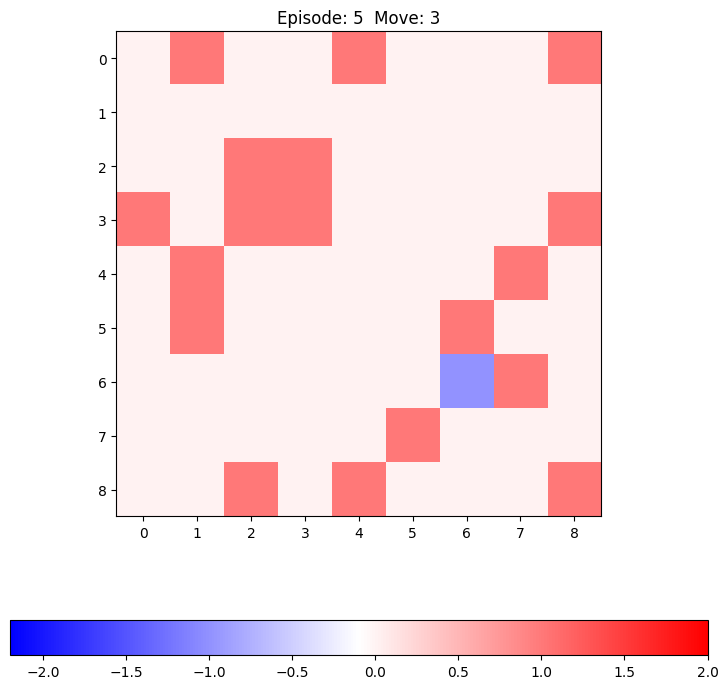

--------------------
Action Taken: Down


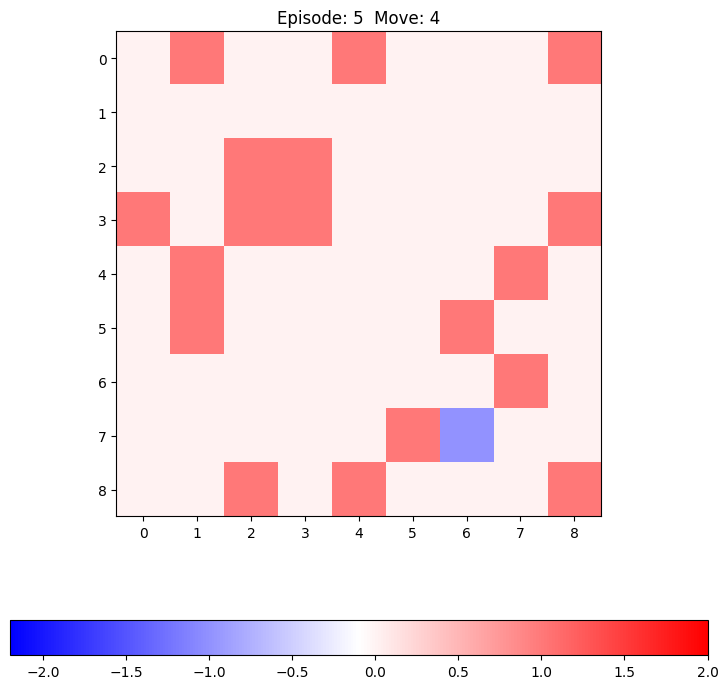

--------------------
Action Taken: Right


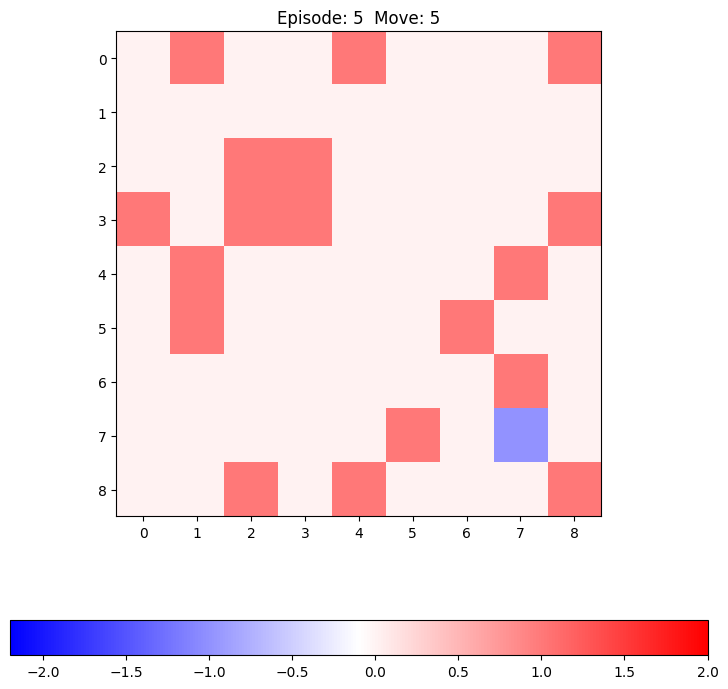

--------------------
Action Taken: Right


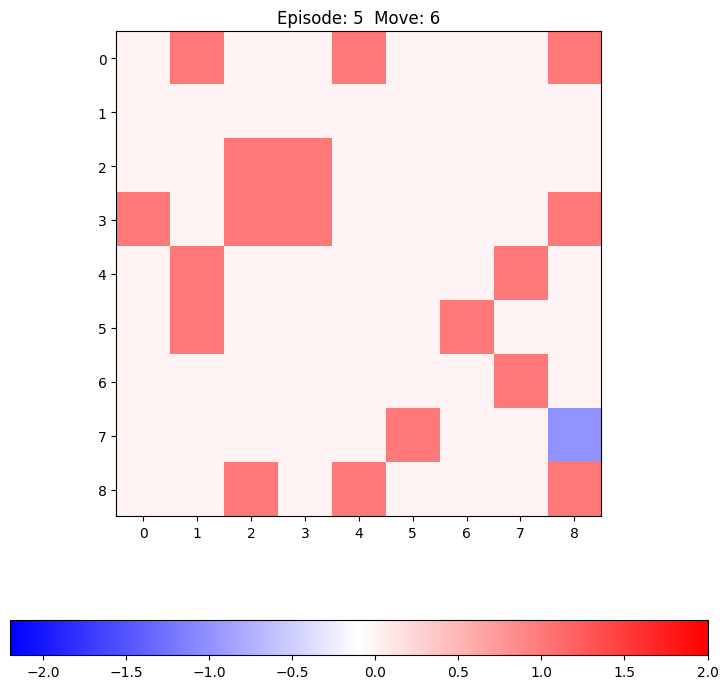

--------------------
Action Taken: Up


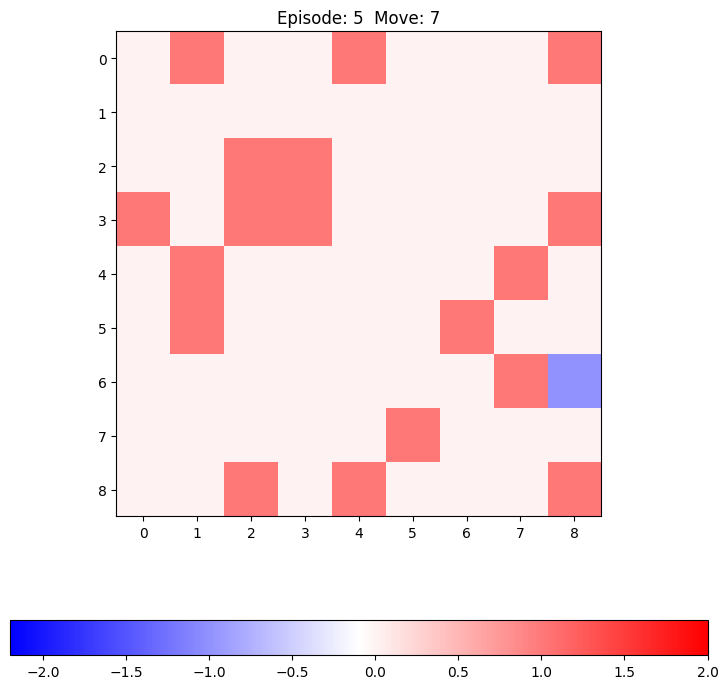

--------------------
Action Taken: Up


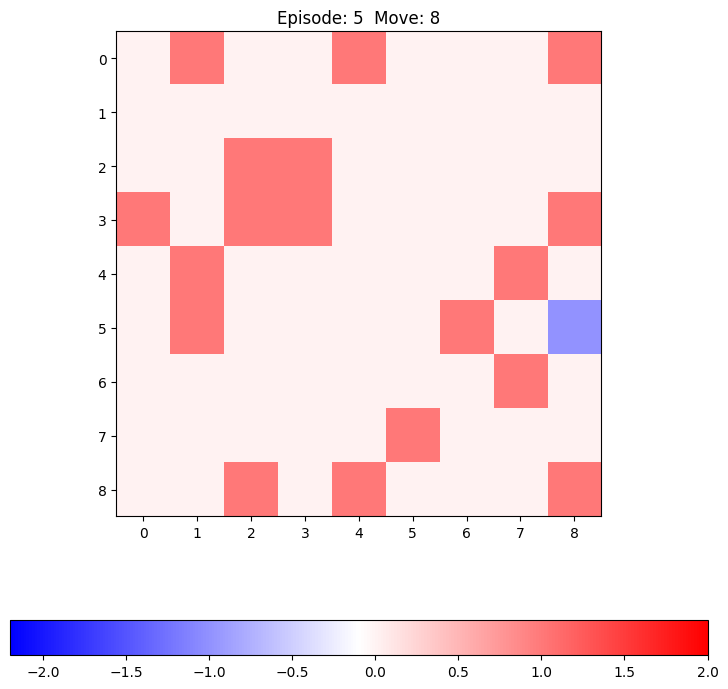

--------------------
Action Taken: Up


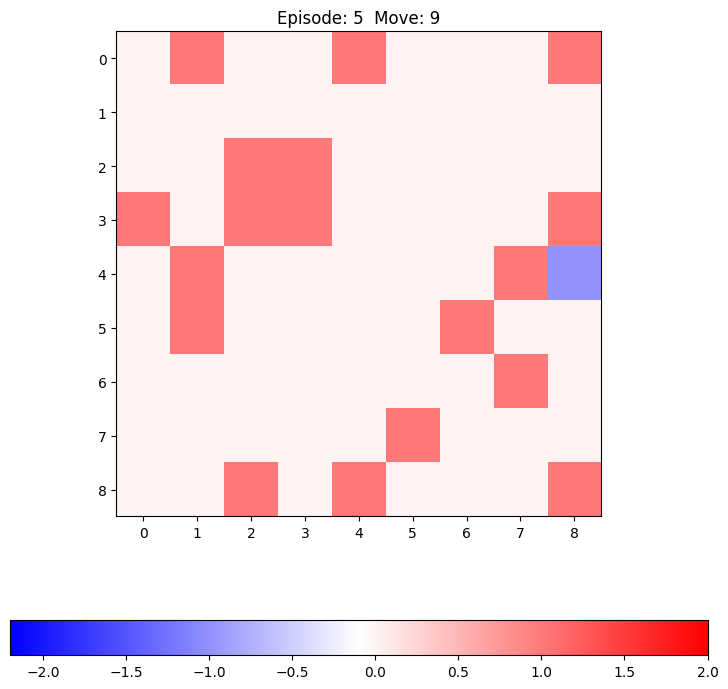

--------------------

Chosen Waypoint: (26, 34)
Action Taken: None


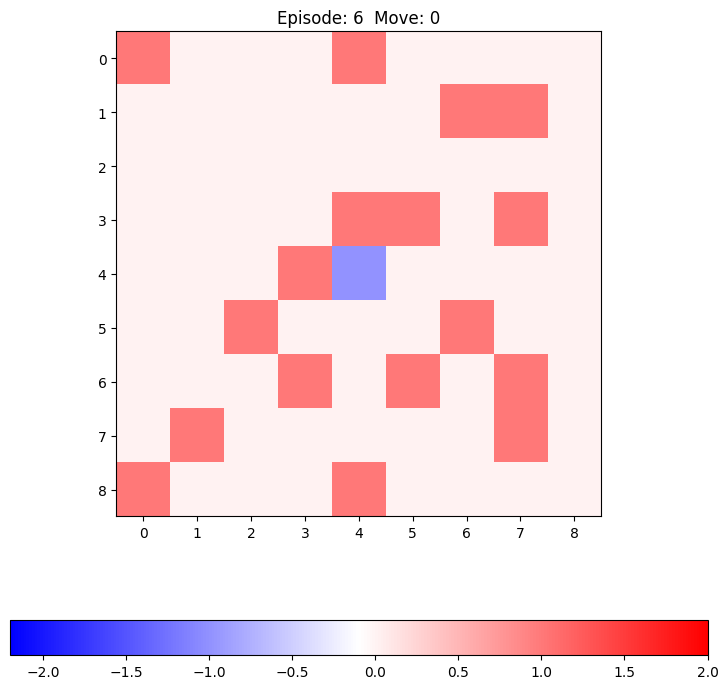

--------------------
Action Taken: Right


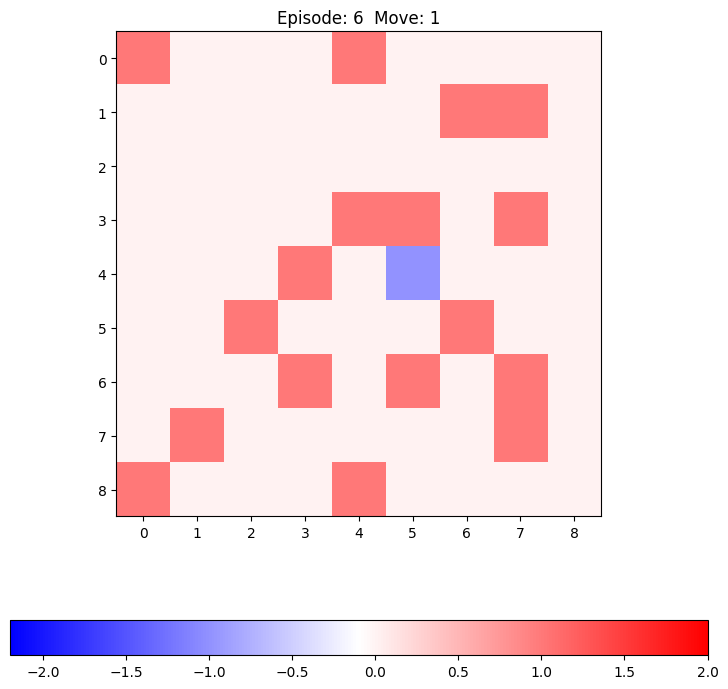

--------------------
Action Taken: Right


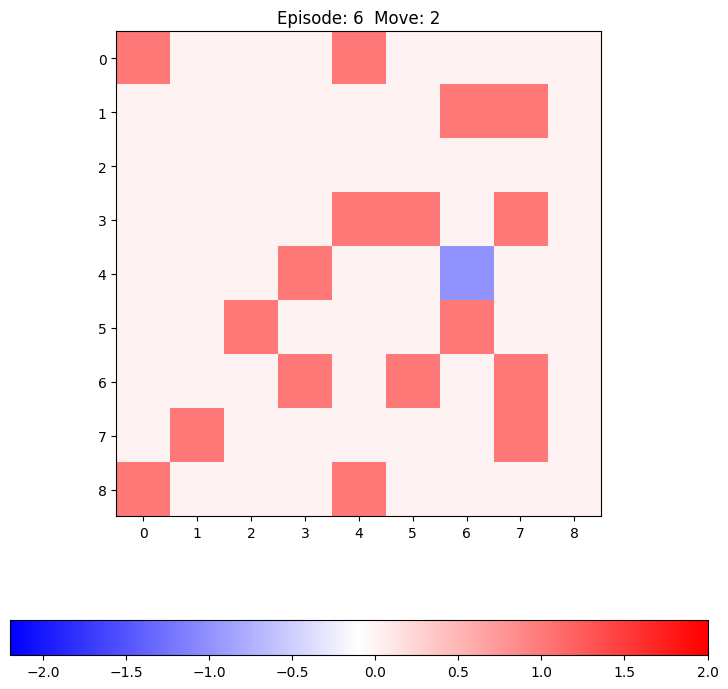

--------------------
Action Taken: Right


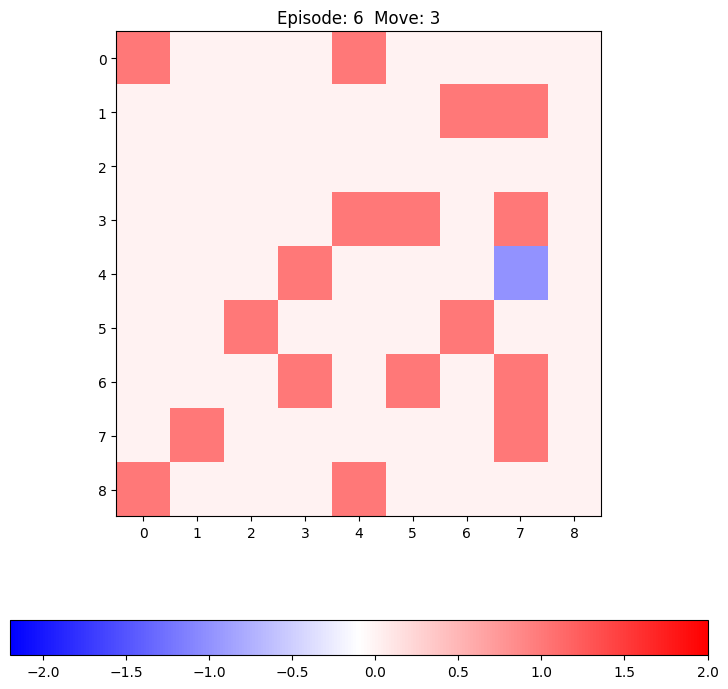

--------------------
Action Taken: Right


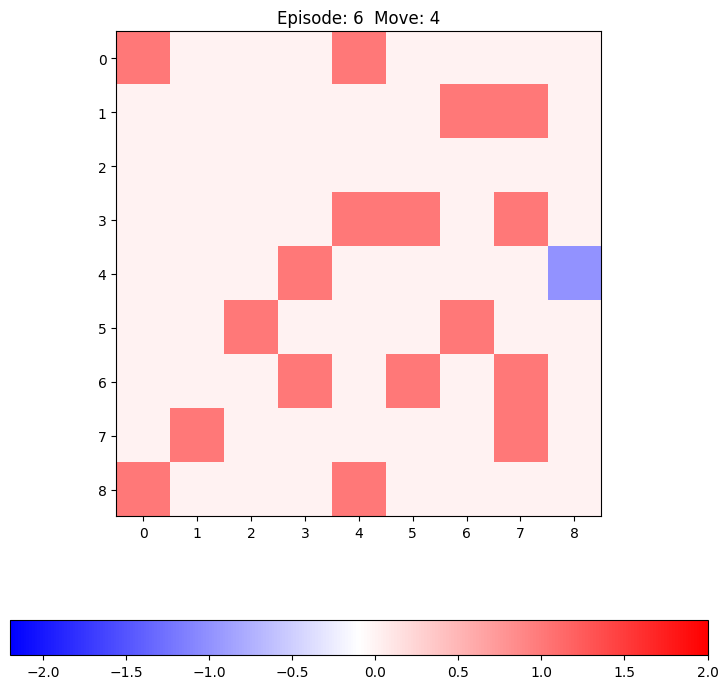

--------------------

Chosen Waypoint: (30, 35)
Action Taken: None


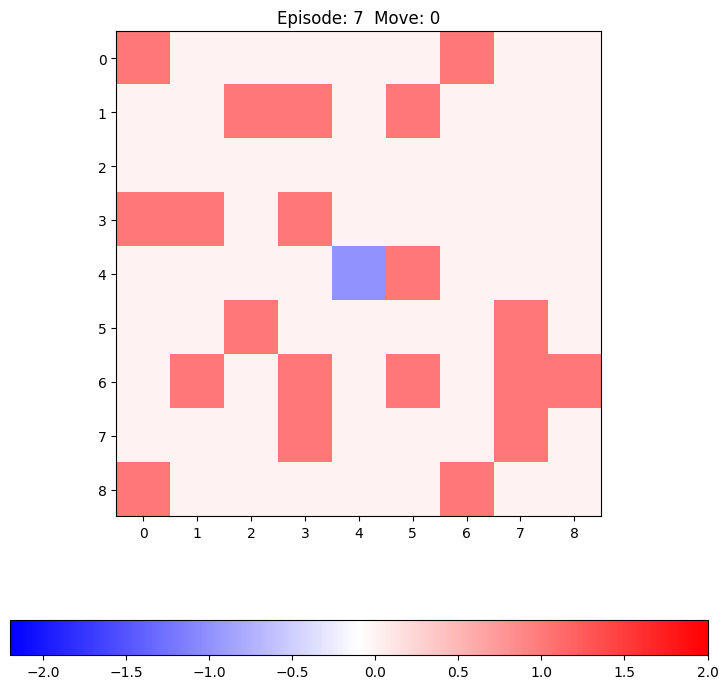

--------------------
Action Taken: Down


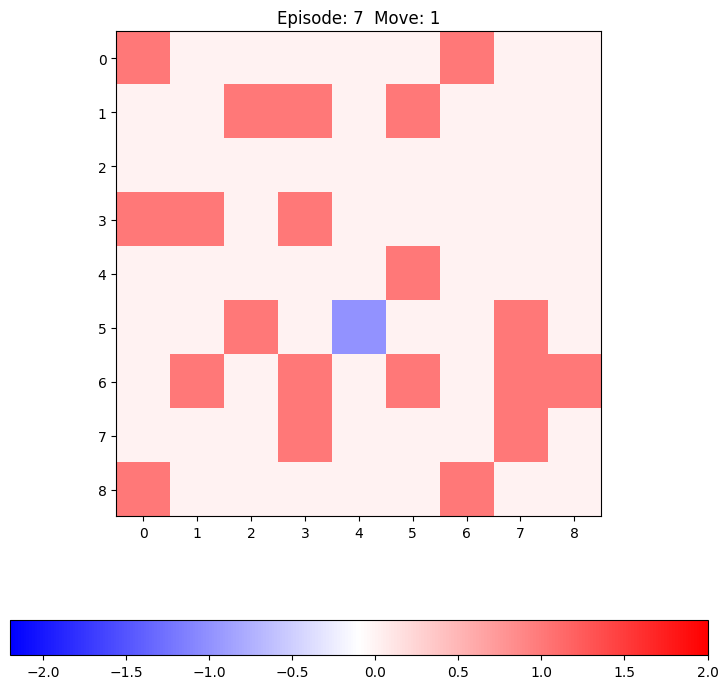

--------------------
Action Taken: Down


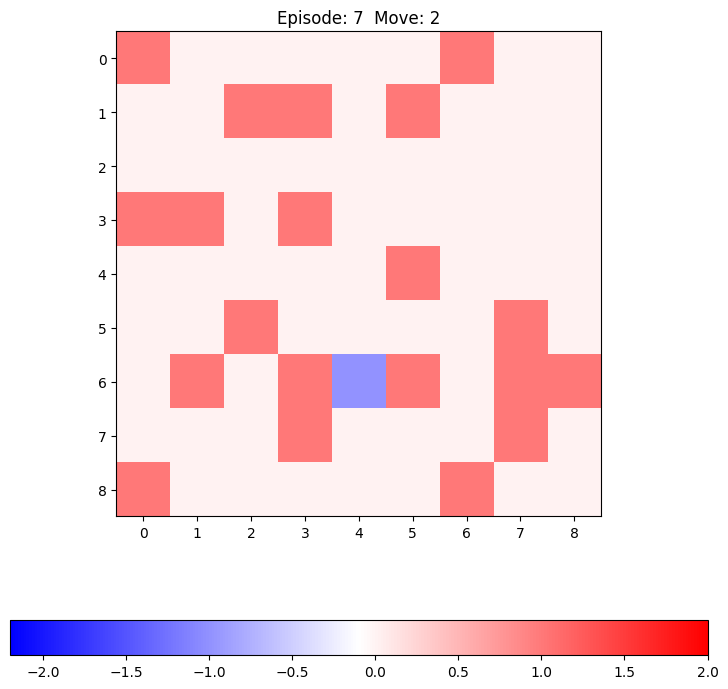

--------------------
Action Taken: Down


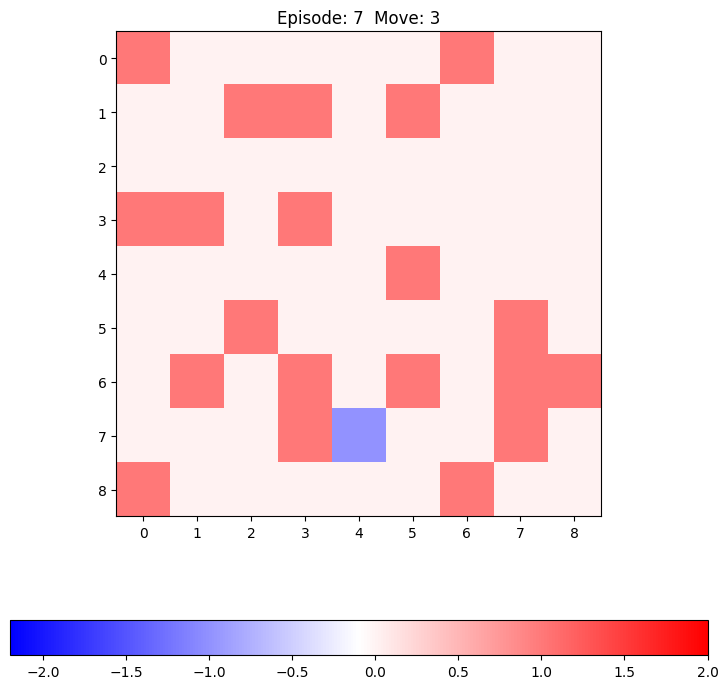

--------------------
Action Taken: Bottom right


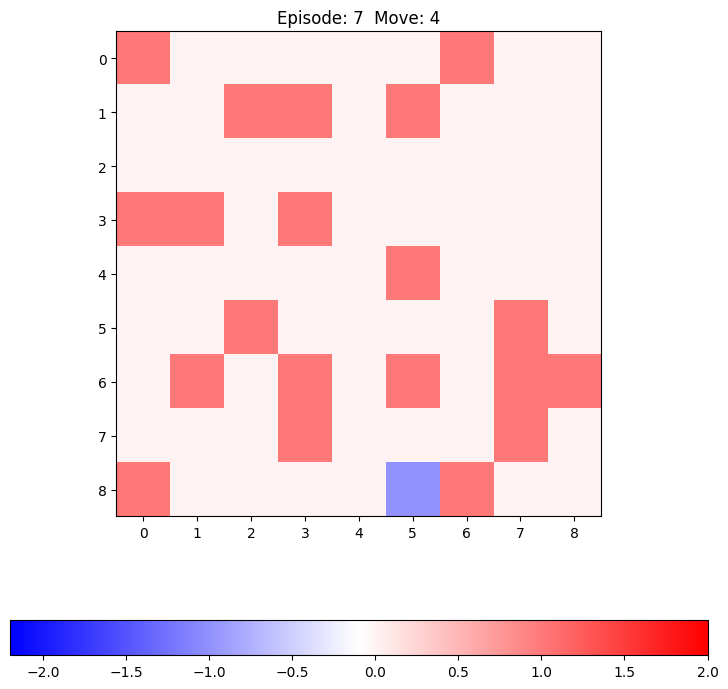

--------------------
Drone has reached the destination: (30, 35)


In [ ]:
# The main loop which runs till destination is reached
while (cur_x, cur_y) != (dest_x, dest_y) and iter < 100:
    lidar_map = get_lidar_obstacles(print_output=False)
    waypoints = generate_waypoint(cur_x, cur_y, dest_x, dest_y, lidar_map, grid_size)
    x,y = cur_x, cur_y

    for waypoint, dist in waypoints:
        print('\nChosen Waypoint:', (waypoint[0]+cur_x-grid_size//2, waypoint[1]+cur_y-grid_size//2))
        path_plan = QLearning(lidar_map, waypoint)
        path_plan.train()
        done, coord = path_plan.visualized_test()

        if done == True:
            cur_x, cur_y = coord[0] + cur_x - grid_size//2, coord[1] + cur_y - grid_size//2
            break

print("Drone has reached the destination:", (cur_x, cur_y))